In [31]:
# auto reload
%load_ext autoreload
%autoreload 2

import pandas as pd
pd.set_option('display.max_rows', None)
import warnings
warnings.filterwarnings('ignore')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
# Wineデータセットを使って汎用性を検証する
from sklearn.datasets import load_wine
from analyze import AnalyzeIris

wine_dataset = load_wine()
print('Keys:', wine_dataset.keys())
print('Target names:', wine_dataset.target_names)
print('Feature names:', wine_dataset.feature_names)
print('Shape:', wine_dataset.data.shape)

Keys: dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])
Target names: ['class_0' 'class_1' 'class_2']
Feature names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Shape: (178, 13)


In [33]:
# AnalyzeIris に wine_dataset を渡すだけで動く
wine = AnalyzeIris(wine_dataset)
wine.describe()


=== AnalyzeIris の使用可能なメソッド ===

  all_supervised(n_neighbors=4)
    → 全分類モデルの交差検証スコアをコンソールに出力する。

  best_supervised()
    → 平均テストスコアが最も高い分類モデルを返す。

  calc_cv_scores(n_neighbors=4)
    → 全分類モデルに対して交差検証スコアを計算する。

  describe()
    → 使用可能なメソッドの一覧と説明を表示する。

  get(head=None)
    → ラベル列を付加したDataFrameを返す。

  get_correlation()
    → 特徴量間の相関係数行列を返す。

  get_supervised()
    → 全分類モデルのテストスコアをDataFrameで返す。

  pair_plot(diag_kind='hist')
    → ペアプロットを表示する。

  plot_feature_importances_all()
    → 木ベースの分類モデルの特徴量重要度を棒グラフで表示する。

  plot_score_comparison()
    → 全分類モデルの平均テストスコアを棒グラフで比較表示する。

  summary()
    → データセットの概要をコンソールに出力する。

  visualize_decision_tree()
    → 決定木の構造を可視化して表示する。



In [34]:
wine.summary()

=== データセット概要 ===

サンプル数   : 178
特徴量数     : 13
クラス数     : 3

クラス分布:
  class_0      :  59 サンプル (33.1%)
  class_1      :  71 サンプル (39.9%)
  class_2      :  48 サンプル (27.0%)

特徴量の統計:
       alcohol  malic_acid      ash  alcalinity_of_ash  magnesium  \
count  178.000     178.000  178.000            178.000    178.000   
mean    13.001       2.336    2.367             19.495     99.742   
std      0.812       1.117    0.274              3.340     14.282   
min     11.030       0.740    1.360             10.600     70.000   
25%     12.362       1.602    2.210             17.200     88.000   
50%     13.050       1.865    2.360             19.500     98.000   
75%     13.678       3.082    2.558             21.500    107.000   
max     14.830       5.800    3.230             30.000    162.000   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count        178.000     178.000               178.000          178.000   
mean           2.295       2.029                 0

In [35]:
wine.get(head=20)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Label
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0,0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0,0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0,0
8,14.83,1.64,2.17,14.0,97.0,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045.0,0
9,13.86,1.35,2.27,16.0,98.0,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045.0,0


In [36]:
# 変数間の相関係数を確認する
wine.get_correlation()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
alcohol,1.000000,0.094397,0.211545,-0.310235,0.270798,0.289101,0.236815,-0.155929,0.136698,0.546364,-0.071747,0.072343,0.643720
malic_acid,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011
ash,0.211545,0.164045,1.000000,0.443367,0.286587,0.128980,0.115077,0.186230,0.009652,0.258887,-0.074667,0.003911,0.223626
alcalinity_of_ash,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597
magnesium,0.270798,-0.054575,0.286587,-0.083333,1.000000,0.214401,0.195784,-0.256294,0.236441,0.199950,0.055398,0.066004,0.393351
total_phenols,0.289101,-0.335167,0.128980,-0.321113,0.214401,1.000000,0.864564,-0.449935,0.612413,-0.055136,0.433681,0.699949,0.498115
flavanoids,0.236815,-0.411007,0.115077,-0.351370,0.195784,0.864564,1.000000,-0.537900,0.652692,-0.172379,0.543479,0.787194,0.494193
nonflavanoid_phenols,-0.155929,0.292977,0.186230,0.361922,-0.256294,-0.449935,-0.537900,1.000000,-0.365845,0.139057,-0.262640,-0.503270,-0.311385
proanthocyanins,0.136698,-0.220746,0.009652,-0.197327,0.236441,0.612413,0.652692,-0.365845,1.000000,-0.025250,0.295544,0.519067,0.330417
color_intensity,0.546364,0.248985,0.258887,0.018732,0.199950,-0.055136,-0.172379,0.139057,-0.025250,1.000000,-0.521813,-0.428815,0.316100


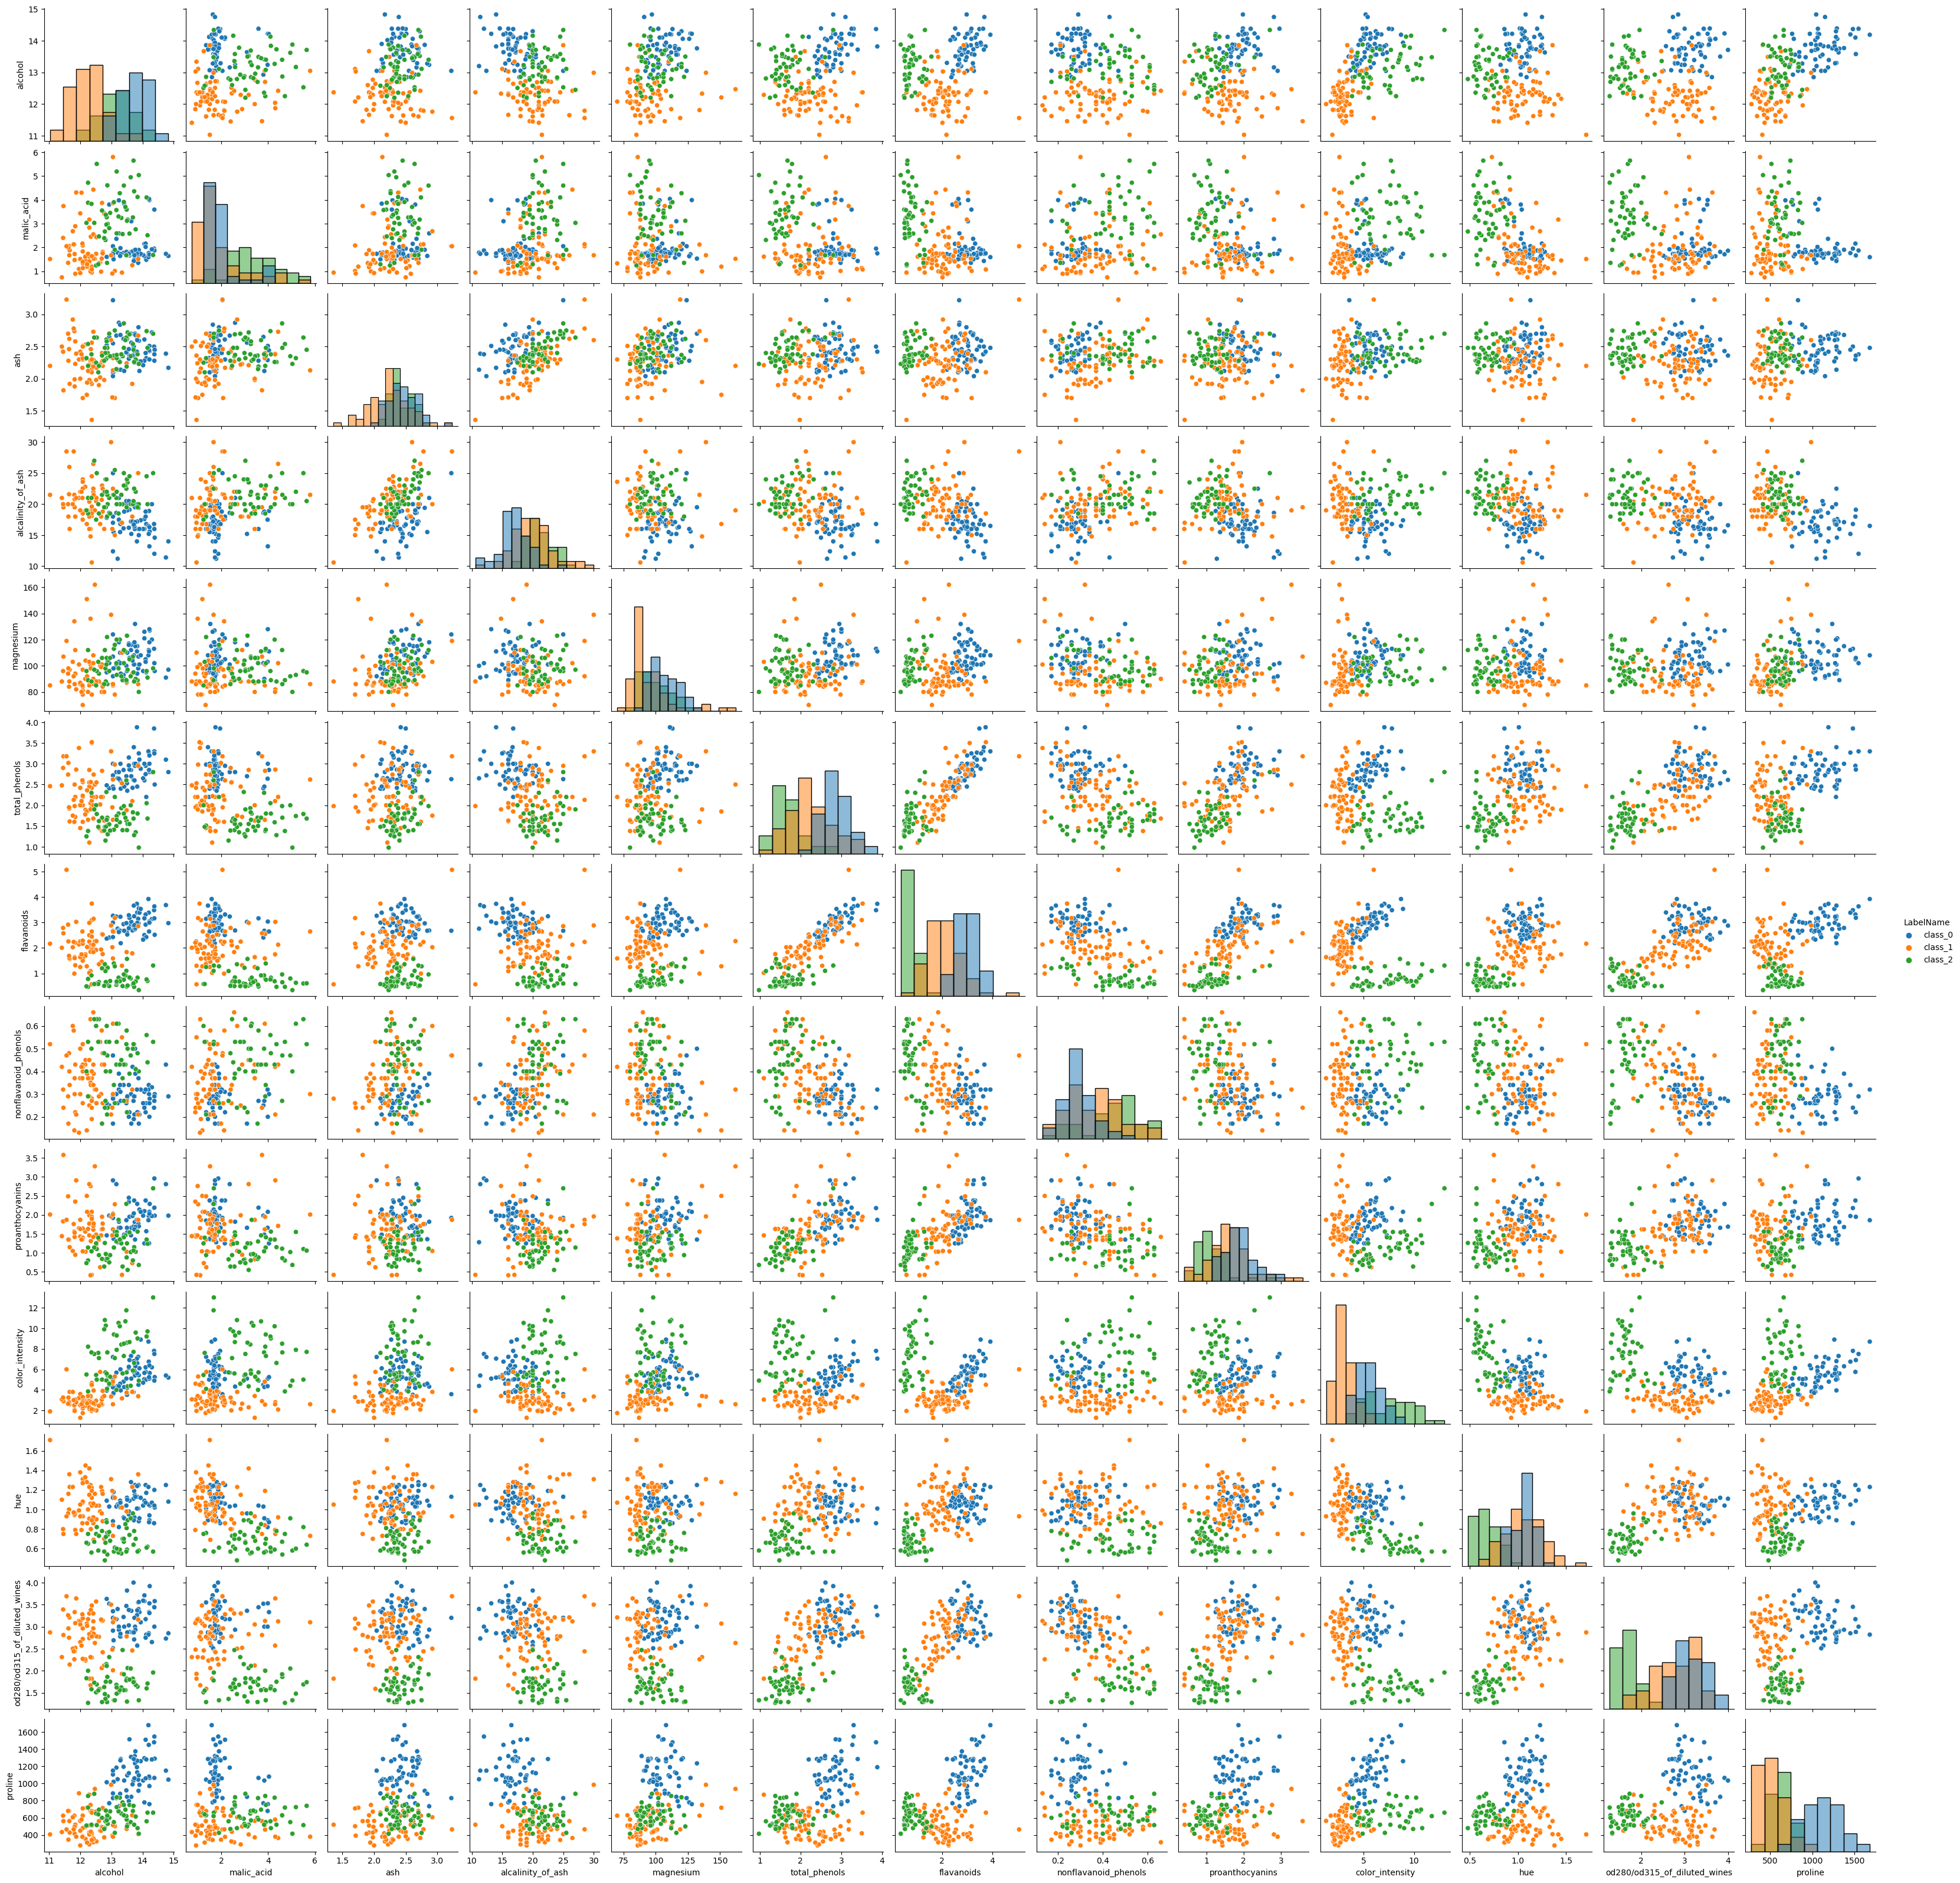

In [ ]:
# ペアプロット（特徴量が多いので代表的な列を確認）
wine.pair_plot()

In [38]:
# 全モデルの交差検証スコアを出力
wine.all_supervised(n_neighbors=4)

== LogisticRegression ==
test score: 0.917, train score: 0.993
test score: 0.972, train score: 0.972
test score: 0.944, train score: 0.993
test score: 1.000, train score: 0.986
test score: 1.000, train score: 0.979

== LinearSVC ==
test score: 0.833, train score: 0.958
test score: 0.917, train score: 0.958
test score: 0.722, train score: 0.859
test score: 0.971, train score: 0.937
test score: 1.000, train score: 0.951

== SVC ==
test score: 0.639, train score: 0.718
test score: 0.611, train score: 0.739
test score: 0.639, train score: 0.718
test score: 0.686, train score: 0.685
test score: 0.743, train score: 0.657

== DecisionTreeClassifier ==
test score: 0.944, train score: 1.000
test score: 0.806, train score: 1.000
test score: 0.917, train score: 1.000
test score: 0.914, train score: 1.000
test score: 0.857, train score: 1.000

== KNeighborsClassifier ==
test score: 0.639, train score: 0.796
test score: 0.694, train score: 0.824
test score: 0.639, train score: 0.824
test score: 0.6

In [39]:
# スコアをDataFrameで確認
df_score = wine.get_supervised()
df_score

,LogisticRegression,LinearSVC,SVC,DecisionTreeClassifier,KNeighborsClassifier,RandomForestClassifier,GradientBoostingClassifier,MLPClassifier
0,0.916667,0.833333,0.638889,0.944444,0.638889,0.972222,0.916667,0.444444
1,0.972222,0.805556,0.611111,0.777778,0.694444,0.944444,0.944444,0.944444
2,0.944444,0.833333,0.638889,0.888889,0.638889,1.000000,0.888889,0.583333
3,1.000000,0.914286,0.685714,0.914286,0.657143,1.000000,0.971429,1.000000
4,1.000000,1.000000,0.742857,0.857143,0.771429,1.000000,0.971429,1.000000


In [40]:
# 統計サマリー
wine.get_supervised().describe()

,LogisticRegression,LinearSVC,SVC,DecisionTreeClassifier,KNeighborsClassifier,RandomForestClassifier,GradientBoostingClassifier,MLPClassifier
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,0.966667,0.900000,0.663492,0.882063,0.680159,0.966508,0.933016,0.765397
std,0.036218,0.115537,0.051834,0.045728,0.055835,0.023196,0.036854,0.341974
min,0.916667,0.750000,0.611111,0.833333,0.638889,0.944444,0.888889,0.166667
25%,0.944444,0.805556,0.638889,0.857143,0.638889,0.944444,0.916667,0.800000
50%,0.972222,0.944444,0.638889,0.861111,0.657143,0.971429,0.916667,0.916667
75%,1.000000,1.000000,0.685714,0.914286,0.694444,0.972222,0.971429,0.971429
max,1.000000,1.000000,0.742857,0.944444,0.771429,1.000000,0.971429,0.972222


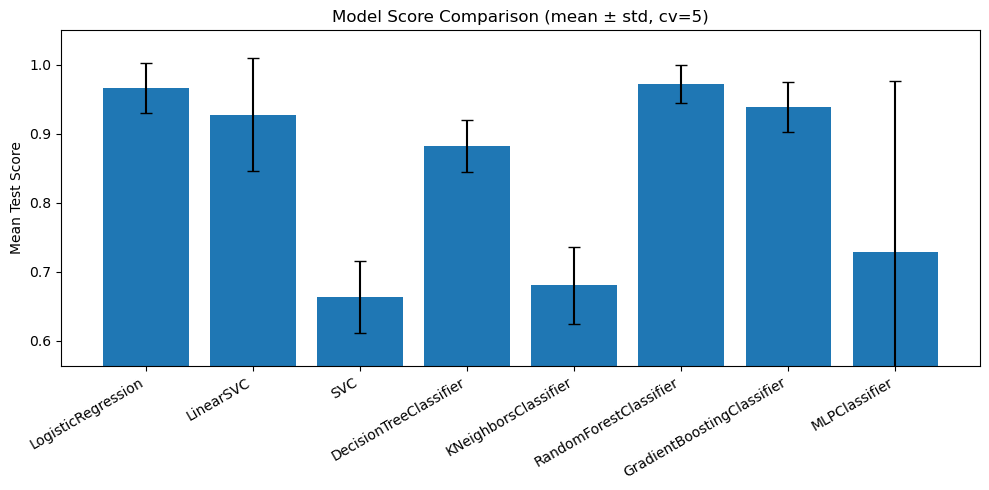

In [41]:
wine.plot_score_comparison()

In [42]:
# 最良モデルを確認
best_method, best_score = wine.best_supervised()
print('BestMethod is ', best_method, ' : ', '{0:0.4f}'.format(best_score))

BestMethod is  RandomForestClassifier  :  0.9722


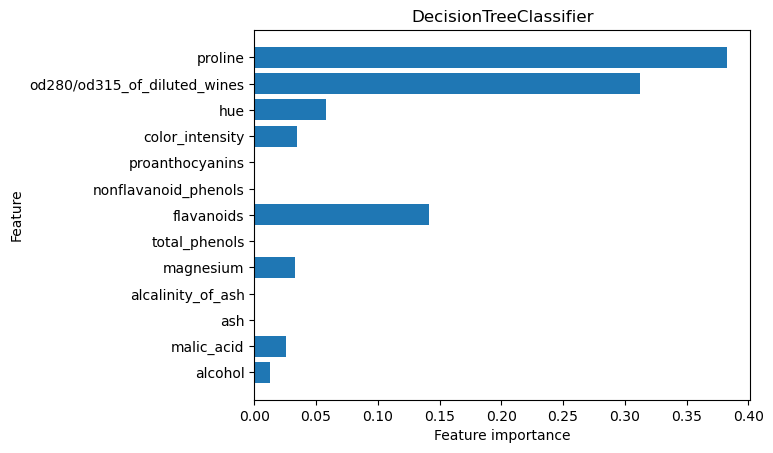

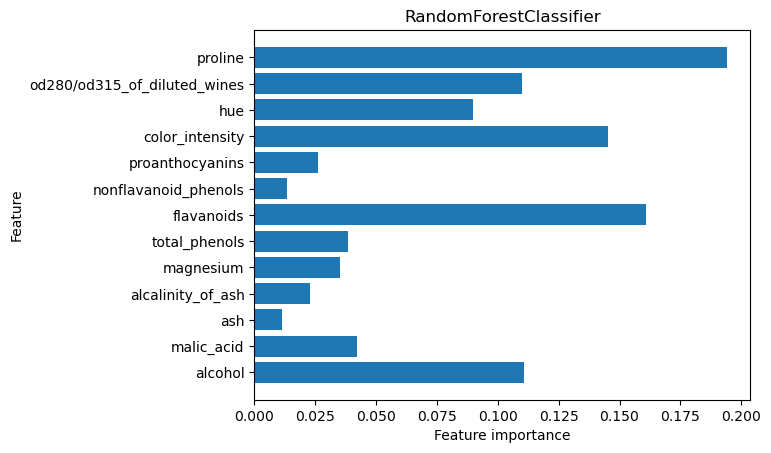

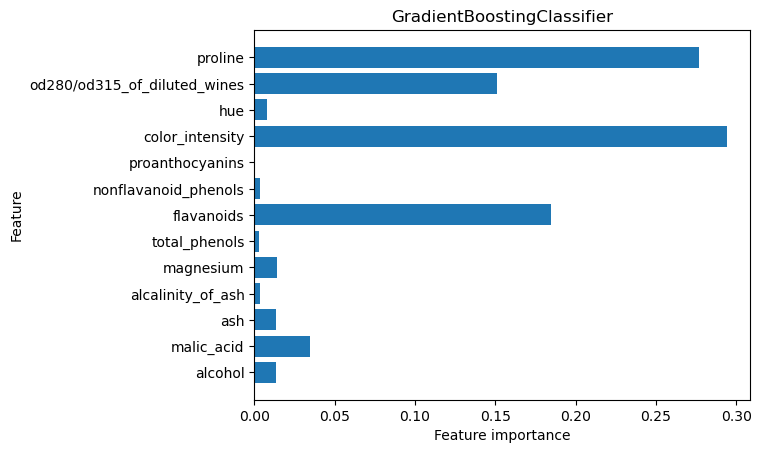

In [43]:
# 特徴量重要度を可視化
wine.plot_feature_importances_all()

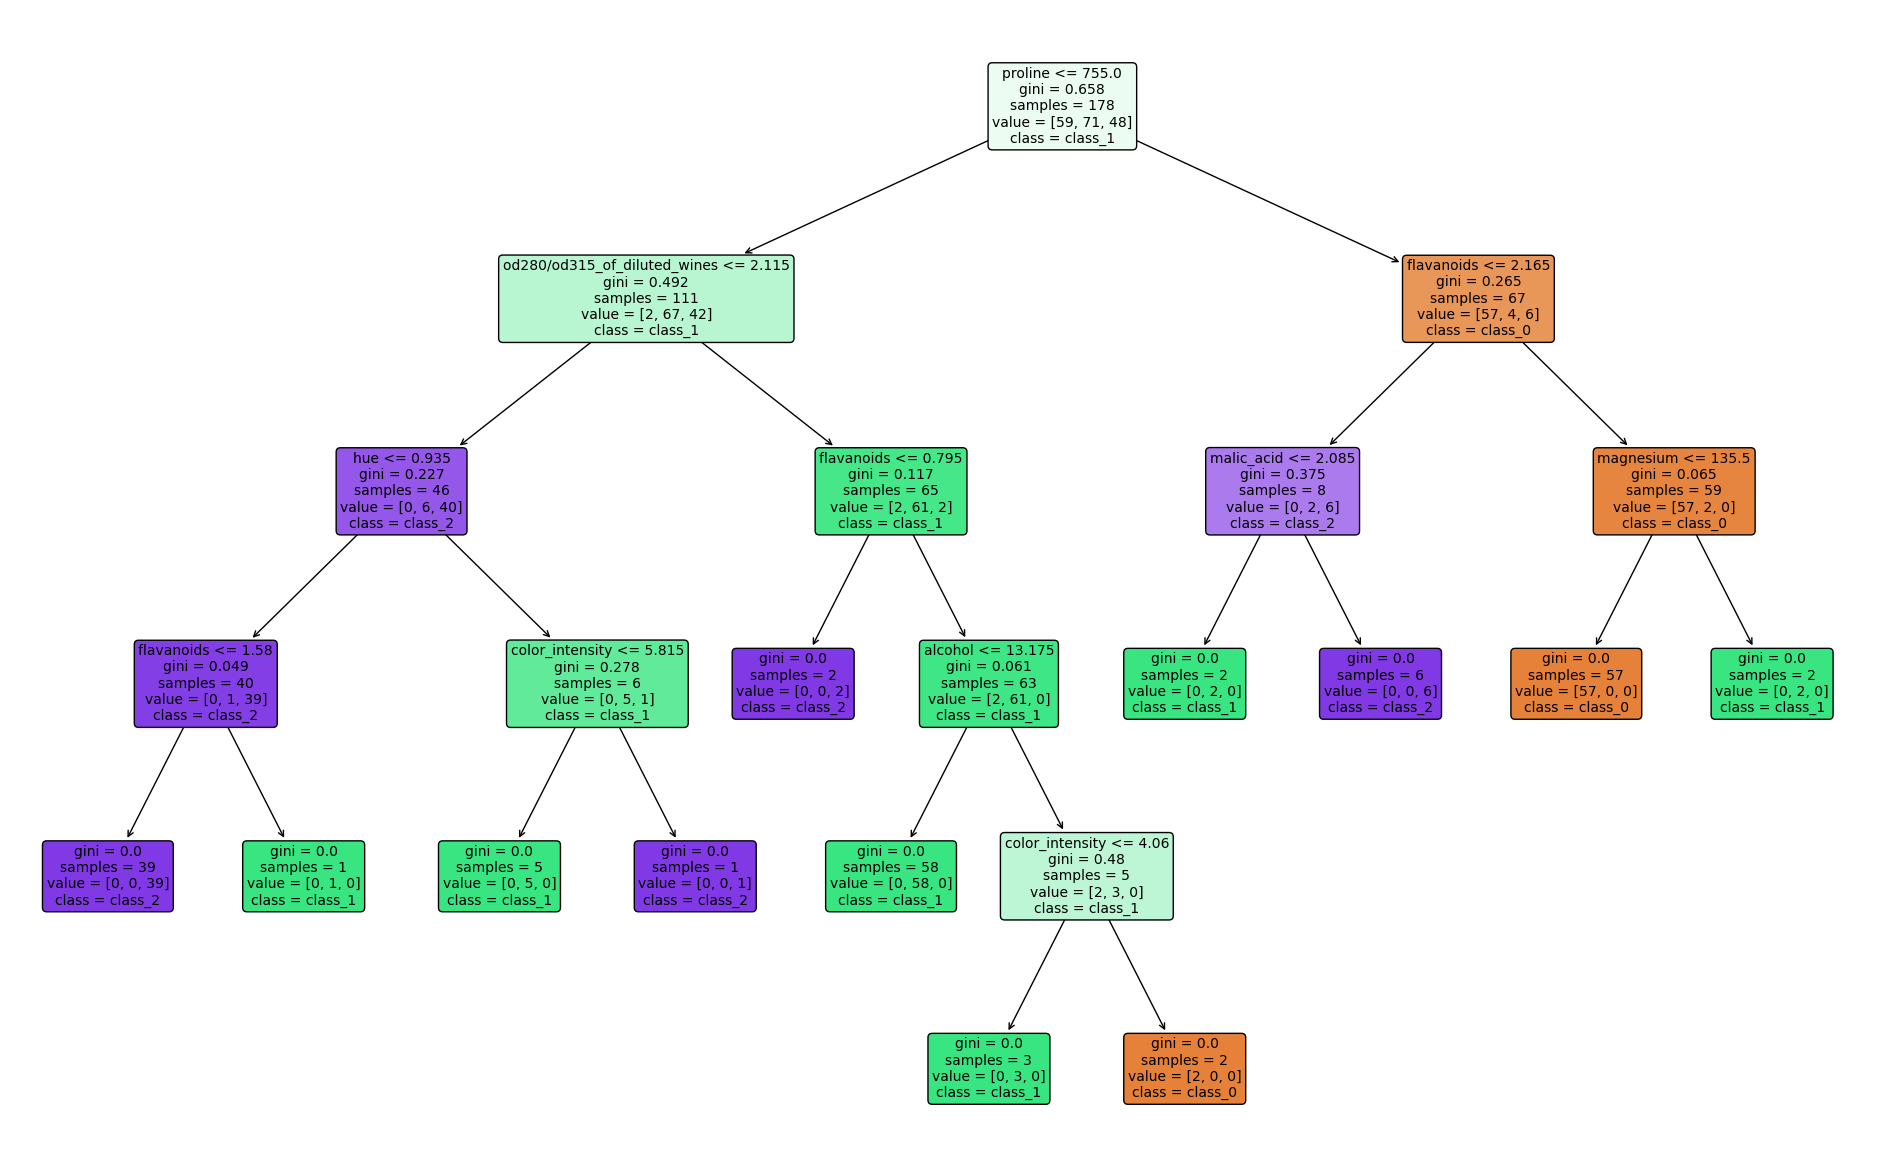

In [44]:
# 決定木を可視化
graph = wine.visualize_decision_tree()